In [68]:
import os 
import sys 

In [69]:
sys.path.append(os.path.abspath("../src"))


In [106]:
from data_loader import load_table
from utils import rfm_seg

In [107]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [108]:
staging_events = load_table('staging_events')

In [109]:
snapshot_date = pd.to_datetime(staging_events[staging_events['event_type'] == 'purchase']['event_datetime']).max()

In [110]:
rfm_seg(staging_events , snapshot_date)

,user_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,U100000,75,5,10966.90,3,4,4,344,Loyal
1,U100001,50,2,7264.52,3,2,3,323,Regular
2,U100002,92,1,3641.52,3,1,1,311,Regular
3,U100003,76,5,16503.05,3,4,4,344,Loyal
4,U100004,70,4,11966.34,3,4,4,344,Loyal
...,...,...,...,...,...,...,...,...,...
10513,U111995,21,1,1272.31,4,2,1,421,New
10514,U111996,92,2,5003.46,3,3,2,332,Regular
10515,U111997,26,3,5069.77,4,4,2,442,New
10516,U111998,210,1,2533.99,1,2,1,121,At Risk


In [111]:
rfm = rfm_seg(staging_events , snapshot_date)

In [112]:
rfm['Segment'].value_counts()/rfm['Segment'].value_counts().sum()*100 # Процент каждого сегмента 

Segment
Loyal      33.571021
Regular    27.343601
At Risk    20.888002
New        10.467770
VIP         7.729606
Name: count, dtype: float64

In [113]:
rfm.groupby('Segment')['Monetary'].mean()

Segment
At Risk     3663.484210
Loyal       9889.130439
New         4582.627039
Regular     4230.162048
VIP        13646.644736
Name: Monetary, dtype: float64

In [114]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Loyal      34918519.58
Regular    12165946.05
VIP        11094722.17
At Risk     8048674.81
New         5045472.37
Name: Monetary, dtype: float64

In [115]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)/rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).sum()#процнент прибыль по сегментам

Segment
Loyal      0.489924
Regular    0.170694
VIP        0.155664
At Risk    0.112927
New        0.070790
Name: Monetary, dtype: float64

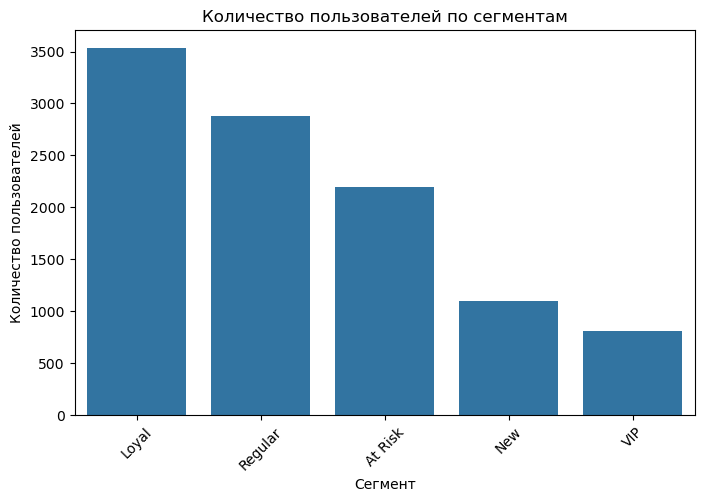

In [116]:

segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=segment_counts.index, y=segment_counts.values)

plt.title("Количество пользователей по сегментам")
plt.ylabel("Количество пользователей")
plt.xlabel("Сегмент")
plt.xticks(rotation=45)
plt.show()

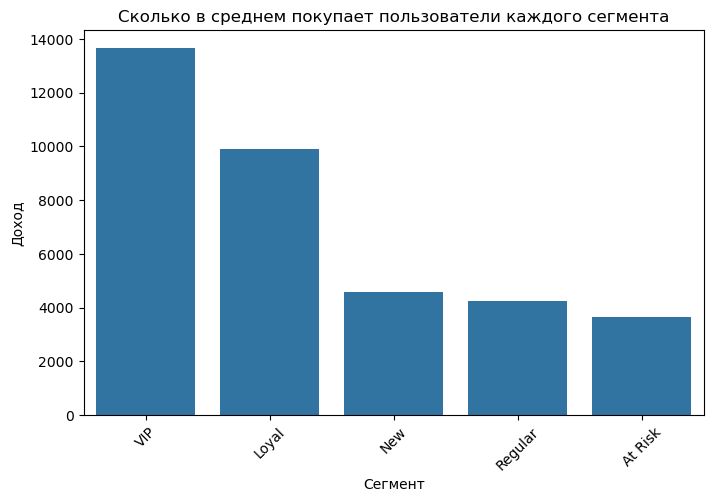

In [117]:
segment_money = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_money.index, y=segment_money.values)

plt.title("Сколько в среднем покупает пользователи каждого сегмента")
plt.ylabel("Доход")
plt.xlabel("Сегмент")
plt.xticks(rotation=45)
plt.show()

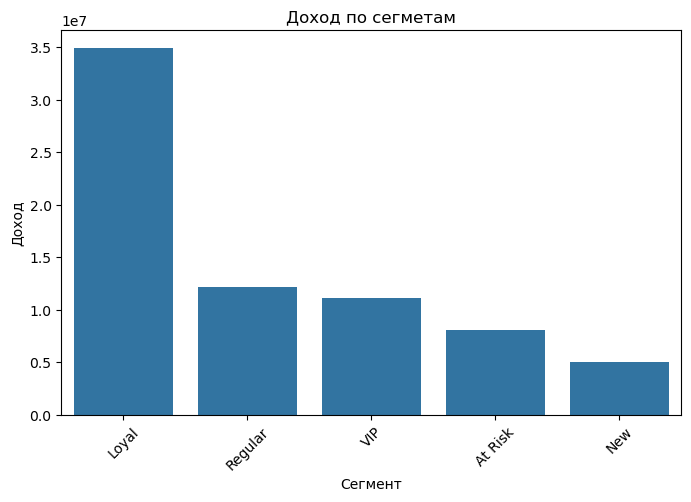

In [118]:
segment_Money=rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=segment_Money.index, y=segment_Money.values)

plt.title("Доход по сегметам")
plt.ylabel("Доход")
plt.xlabel("Сегмент")
plt.xticks(rotation=45)
plt.show()

### Основные исайты из RFM 

1. Более 60% всех пользователей это Loyal и Regular . Это говорит о сформированости клиентской базы лояльных клиентов , которые обеспечивают стабильность платформы 
2. Средний чек VIP клиента ~3 раз больче чем у new клиента , этого говорит , о том что выгоде удеожать 1 VIP клиента чем привлечь двух новых , из этого следует , что стоит пересчитать расходы на удержания 1 VIP клианта и CAC для 1 нового клиента 
3. Основное "ядро" которое приносит деньги это Loyal (~34% Базы) , не смотря на их многочисленость , их срдений чек состовляет ~9к , и они генерируют 48% дохода
4. Сегмент New (10.5%) показывает средний чек (~4,500), что выше, чем у группы риска. Это «точка роста»: если перевести их в разряд Loyal, доходность бизнеса вырастет в 2 раза.

### Бизнесc рекомендации :
1. Retention VIP-сегмента: Удержание одного VIP-клиента равносильно привлечению 2-3 новых. Рекомендуется внедрение закрытых программ лояльности и персональных предложений. 
2. Реактивация At Risk: Необходимо провести рассылку с оффером для возвращения. Однако, учитывая их низкий средний чек, затраты на их реактивацию не должны превышать потенциальную прибыль.
3. Конверсия New → Loyal: Основная задача маркетинга — стимулировать вторую и третью покупку у новых пользователей, так как именно на этом этапе их средний чек вырастает с 4.5к до 9.8к.